# **EXPLORATORY DAYA ANALYSIS AND PREPROCESSING**
**Fadhlan Nur Rachman - 2802491690**

Data Dictionary :
- survival:	Survival	0 = No, 1 = Yes
- pclass:	Ticket class	1 = 1st, 2 = 2nd, 3 = 3rd
- sex:	Sex
- Age:	Age in years
- sibsp	# of siblings / spouses aboard the Titanic
- parch	# of parents / children aboard the Titanic
- ticket:	Ticket number
- fare:	Passenger fare
- cabin:	Cabin number
- embarked:	Port of Embarkation	C = Cherbourg, Q = Queenstown, S = Southampton

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

train_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/LAB ML/titanic/train.csv')
test_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/LAB ML/titanic/test.csv')

print("Train Data Shape:", train_data.shape)
print("Test Data Shape:", test_data.shape)

Train Data Shape: (891, 12)
Test Data Shape: (418, 11)


#### Interpretasi cell diatas :
terdapat data train dan data test dengan masing masing ukuran (baris, kolom atau variable),
kita bisa melihat bahwa variable train dan test berbeda karena pada data test tidak ada kolom target (survived)


In [3]:
train_data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### Interpretasi cell diatas :
memuat data lebih jelas pada data train


In [4]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


#### Interpretasi cell diatas :
memuat data lebih jelas pada data test


In [5]:
cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
train_data = train_data.drop(columns=cols_to_drop)
test_data = test_data.drop(columns=cols_to_drop)

#### Interpretasi cell diatas :
PassengerId, Name, Ticket, dan Cabin dihapus karena variable ini bertipe string dengan unique value yang tinggi atau memiliki banyak data hilang, sehingga data tersebut tidak bisa memberikan pola statistik


In [6]:
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


#### Interpretasi cell diatas :
Hasil data train setelah menghapus variable PassengerId, Name, Ticket, dan Cabin


In [7]:
test_data.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S


#### Interpretasi cell diatas :
Hasil data test setelah menghapus variable PassengerId, Name, Ticket, dan Cabin


## Exploratory Data Analysis

In [8]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


#### Interpretasi cell diatas :
cek informasi dari data train terdapat info tipedata dari setiap variable ada 2 float, 4 integer, dan 2 object atau kategorikal data. serta terdapat banyaknya baris yang memiliki isi dari setiap variable nya. dan disini kita bisa mengetahui data lengkap seluruhnya terisi ada 891 dan jika ada variable yang tidak 891 berarti ada missing value


### EDA Non-Graphical

In [9]:
train_data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#### Interpretasi cell diatas :
terdapat hasil statistik data numerical yang bisa menunjukkan distribusi serta kesimpulan dari setiap data nya dan bisa jadi insight untuk kita seperti contoh "rata-rata umur penumpang adalah sekitar 29.7 tahun" lalu ada "tarif(Fare) memiliki standar deviasi yang sangat tinggi 49.69 yang menunjukan adanya kesenjangan harga tiket yang lebar" dan berbagai informasi menarik lainnya


In [10]:
train_data.describe(include=['O']  )

,Sex,Embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


#### Interpretasi cell diatas :
terdapat hasil statistik data kategorikal yang menunjukan distribusi jumlah penumpang berdasarkan jenis kelamin(Sex) dan pelabuhan keberangkatan(Embarked). dan ada juga mayoritas seperti penumpang banyak yang naik dari pelabuhan 'S' (Southampton) dan jenis kelamin terbanyak jatuh kepada lelaki dengan frekuensi muncul sebanyak 577

In [11]:
# check missing values

missing_summary_values = pd.DataFrame({
    'Missing Count': train_data.isnull().sum(),
    'Missing Percentage': (train_data.isnull().mean() * 100).round(2)
})

missing_summary_values

,Missing Count,Missing Percentage
Survived,0,0.00
Pclass,0,0.00
Sex,0,0.00
Age,177,19.87
SibSp,0,0.00
Parch,0,0.00
Fare,0,0.00
Embarked,2,0.22


#### Interpretasi cell diatas :
Melihat sebuah missing value yang lebih lengkap dimana ternyata terdapat sebuah persentase yang menunjukan 19.86% data umur(Age) ada baris yang hilang serta 0.22% pelabuhan keberangkatan(Embarked) ada baris yang hilang juga

### EDA Multivariate Non-Graphical

In [12]:
# Cross Tabulation

sex_embarked_ct = pd.crosstab(train_data['Sex'], train_data['Embarked'], dropna=False)

sex_embarked_ct

Embarked,C,Q,S,NaN
Sex,,,,
female,73,36,203,2
male,95,41,441,0


#### Interpretasi cell diatas :
Menunjukkan distribusi jumlah penumpang berdasarkan jenis kelamin dan pelabuhan keberangkatan. Mayoritas penumpang naik dari pelabuhan 'S' (Southampton) dan sebagai contoh informasi "di pelabuhan southampton terdapat 203 penumpang perempuan yang naik ke kapal"

###EDA  Univariate Graphical

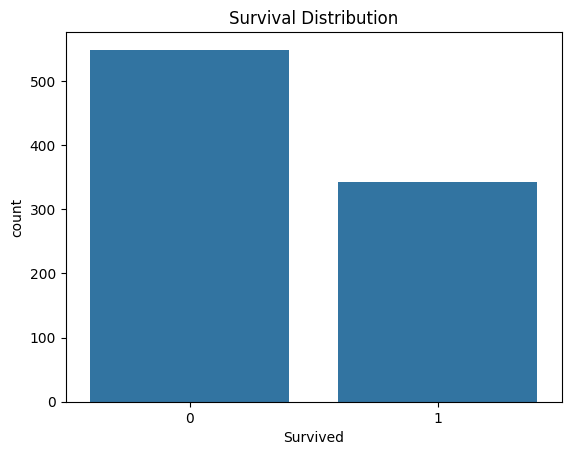

In [13]:
# Bar Chart for Survival Distribution
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Survived', data=train_data)
plt.title('Survival Distribution')
plt.show()

#### Interpretasi cell diatas :
Terlihat Data target tidak seimbang. jumlah penumpang yang tidak selamat(survived = 0) jauh lebih banyak daripada yang selamat(survived = 1)

Text(0.5, 1.0, 'Age Distribution')

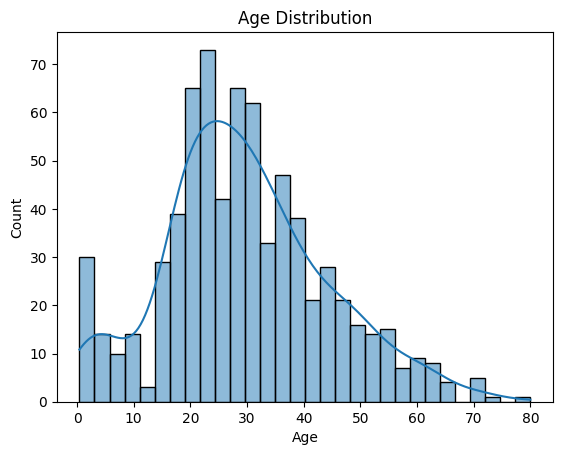

In [14]:
# Histogram for Age Distribution

sns.histplot(train_data['Age'], bins=30, kde=True)
plt.title('Age Distribution')

#### Interpretasi cell diatas :
Distribusi histogram umur mendekati kurva normal namus sedikit miring ke kanan(right-skewed), dengan konsentrasi penumpang terbesar berada diusia produktif(20-40 tahun).

###EDA Multivariate Graphical

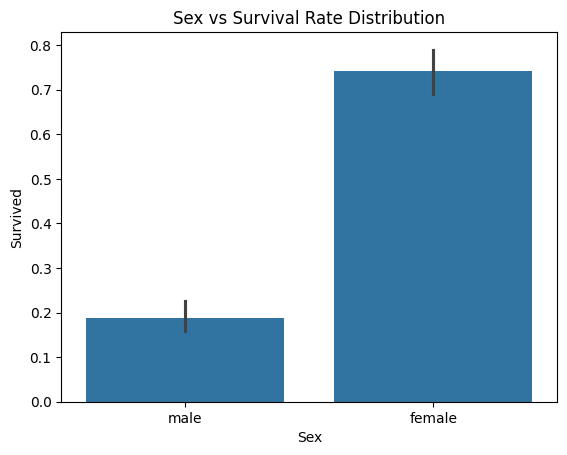

In [15]:
# Sex vs Survival Rate Distribution
sns.barplot(x='Sex', y='Survived', data=train_data)
plt.title('Sex vs Survival Rate Distribution')
plt.show()

#### Interpretasi cell diatas :
Terdapat perbedaan drastis pada tingkat keselamatan. Perempuan memiliki peluang selamat yang jauh lebih tinggi dibandingkan laki-laki. Ini membuktikan juga aturan wanita didahulukan saat evakuasi.

Text(0.5, 1.0, 'Age vs Survival Distribution')

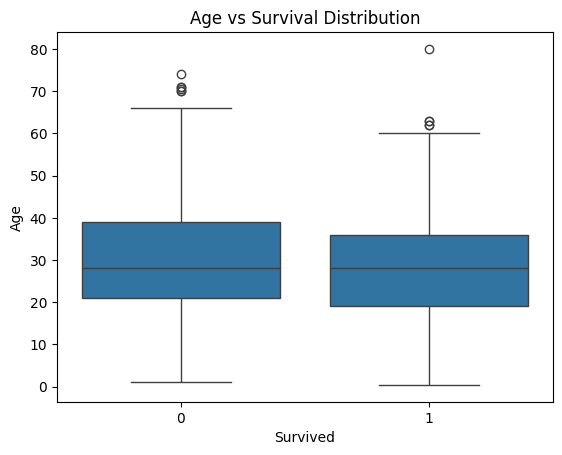

In [16]:
# age vs survived distribution
sns.boxplot(x='Survived', y='Age', data=train_data)
plt.title('Age vs Survival Distribution')

#### Interpretasi cell diatas :
Rentang umur pada kedua kelompok (selamat/tidak selamat) serupa. Namun, pada kelompok selamat, terdapat variasi umur yang lebih lebar di bagian bawah (anak-anak), menunjukkan prioritas keselamatan pada usia muda. lalu kita bisa lihat juga di boxplot terdapat beberapa outlier yang keluar

## Data Preprocessing

In [17]:
#Age Impution with Mean
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].mean())

#### Interpretasi cell diatas :
Mengisi missing value variable umur(Age) menggunakan rata-rata(Mean) karena umur adalah data numerik yang distribusi nya cukup padat

In [18]:
#Embarked Impution with Mode
train_data['Embarked'] = train_data['Embarked'].fillna(train_data['Embarked'].mode()[0])

#### Interpretasi cell diatas :
Mengisi missing value variable Pelabuhan Keberangkatan(Embarked) karena hanya 2 data hilang ktia menggunakan modus karena umur adalah data kategorikal, maka diisi dengan nilai yang paling sering muncul.

In [19]:
train_data.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


#### Interpretasi cell diatas :
Setelah proses mengisi missing value bisa dilihat sekarang sudah tidak ada lagi data yang hilang atau tidak terisi

In [20]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in ['Sex', 'Embarked']:
    train_data[col] = le.fit_transform(train_data[col])

#### Interpretasi cell diatas :
Mengubah data kategorikal menjadi angka agar bisa dibaca algoritma dan komputer, dimana contoh: (Male/Female) menjadi 0 dan 1

In [21]:
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


#### Interpretasi cell diatas :
Konfirmasi data kategorikal sudah berubah menjadi numerical yang sudah bisa dibaca oleh komputer

In [22]:
# Data Transformation using Standar Scaler (Z-Score)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scale_cols = ['Age', 'Fare']
train_data[scale_cols] = scaler.fit_transform(train_data[scale_cols])


#### Interpretasi cell diatas :
transformasi atau standarisasi kolom umur(age) dan tarif(fare) memiliki skala yang sangat tinggi dengan data yang lainnya dan standarisasi mengubah data sehingga memiliki rata-rata = 0 dan standar deviasi = 1, lalu standar scaler(z-score) ini memiliki rentang dari -1 hingga 1

In [23]:
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,-0.592481,1,0,-0.502445,2
1,1,1,0,0.638789,1,0,0.786845,0
2,1,3,0,-0.284663,0,0,-0.488854,2
3,1,1,0,0.407926,1,0,0.420730,2
4,0,3,1,0.407926,0,0,-0.486337,2


#### Interpretasi cell diatas :
hasil transformasi atau standarisasi variable umur(age) dan tarif(fare)

## Additional Info

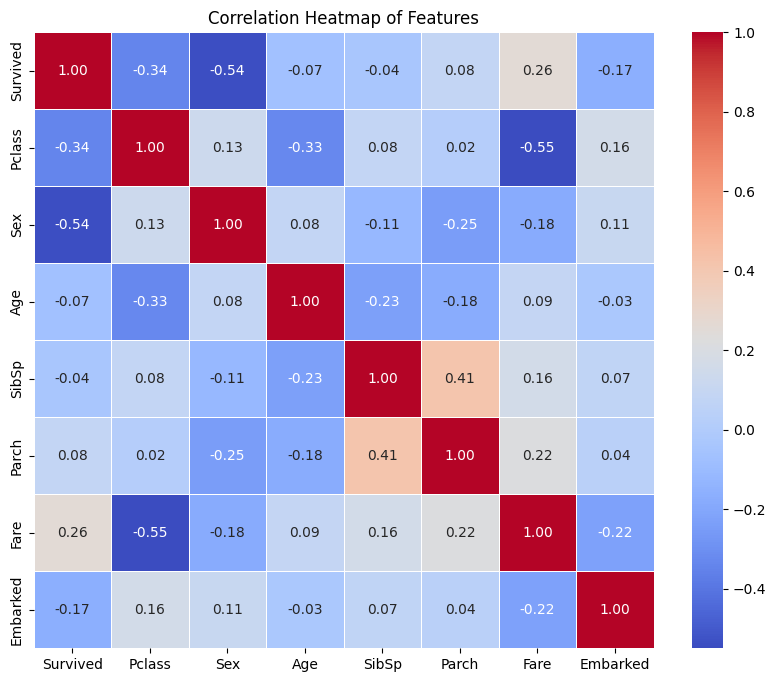

In [24]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(train_data.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Features')
plt.show()

#### Interpretasi cell diatas :
Heatmap ini merangkum seluruh hubungan antar fitur. seperti contoh korelasi negatif yang kuat antara Sex dan Survived memperkuat temuan bahwa jenis kelamin adalah variable prediktor terkuat dalam dataset ini.